In [6]:
import pandas as pd
import numpy as np
import yfinance as yf

In [7]:
# Holt-Winters (Triple Exponential Smoothing) models:

# Level + Trend + Seasonality

In [8]:
data=yf.download('AAPL',start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [21]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404022,186.170300,181.675100,184.895829,82488700
2024-01-03,182.030777,183.641149,181.220646,182.001140,58414500
2024-01-04,179.718933,180.884713,178.701340,179.956033,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [9]:
df=data.iloc[:,0]

In [10]:
df.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 667 entries, 2024-01-02 to 2026-08-28
Series name: ('Close', 'AAPL')
Non-Null Count  Dtype  
--------------  -----  
666 non-null    float64
dtypes: float64(1)
memory usage: 10.4 KB


In [11]:
df.dropna(inplace=True)

In [20]:
df.head()

Date
2024-01-02    183.404022
2024-01-03    182.030777
2024-01-04    179.718933
2024-01-05    178.997726
2024-01-08    183.324966
Name: (Close, AAPL), dtype: float64

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

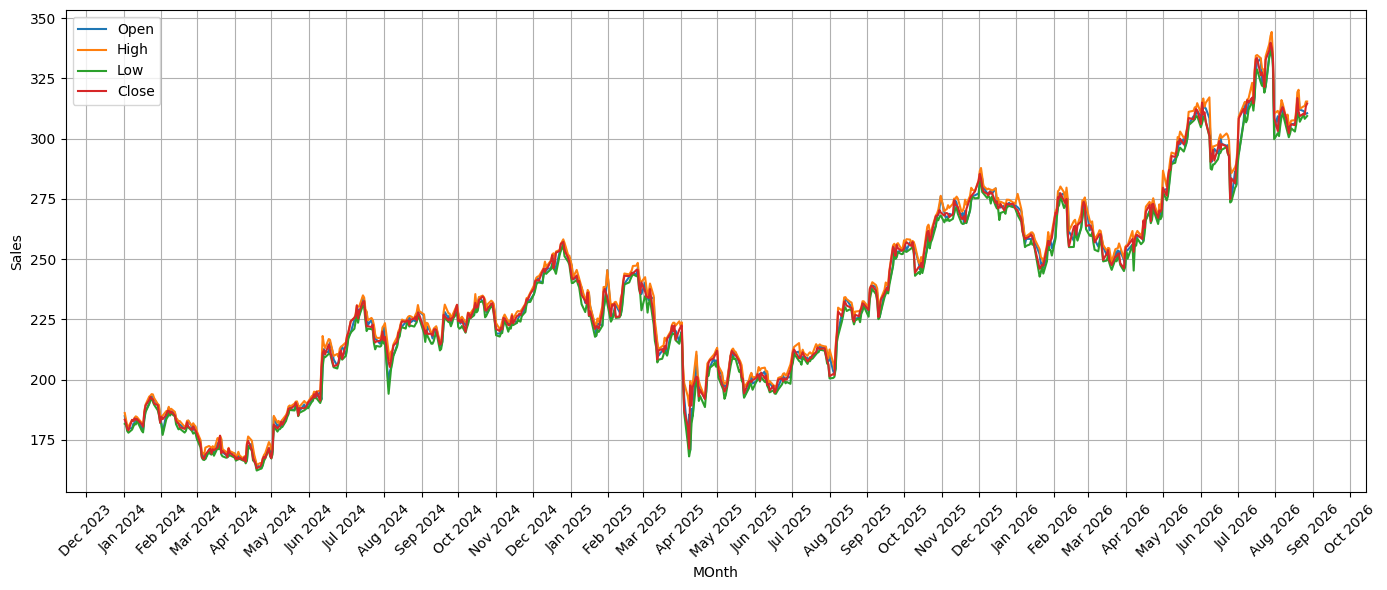

In [13]:
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(data.index, data[col], label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

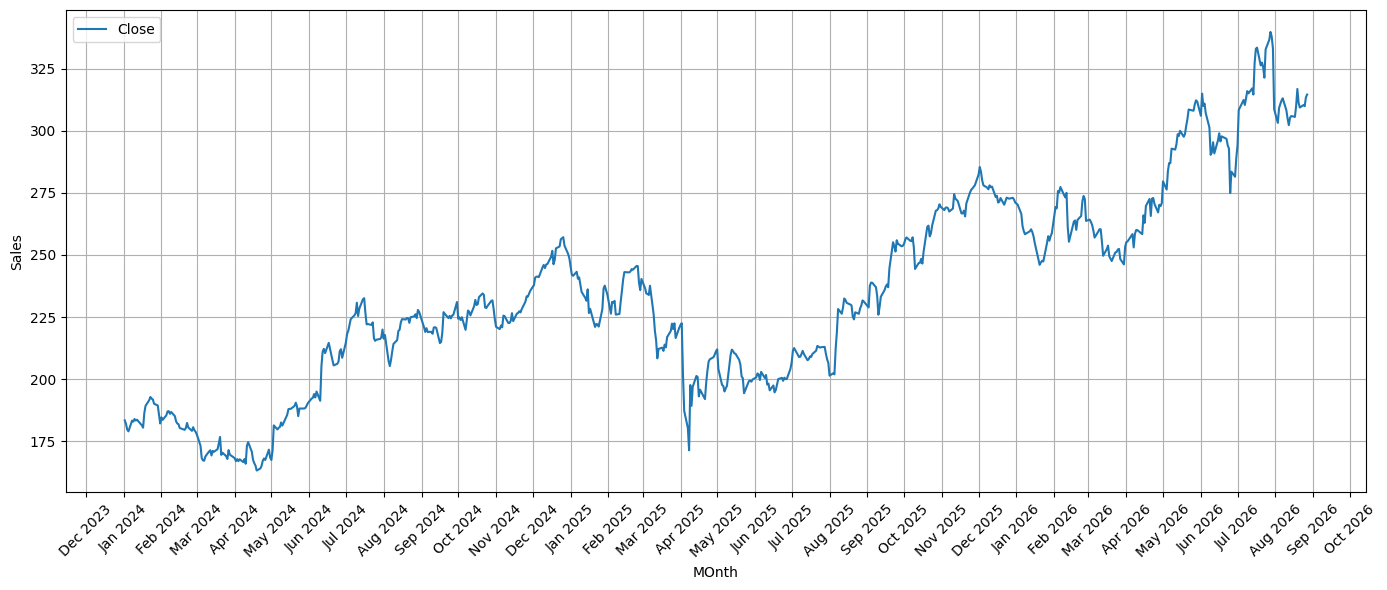

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df, label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1400x500 with 0 Axes>

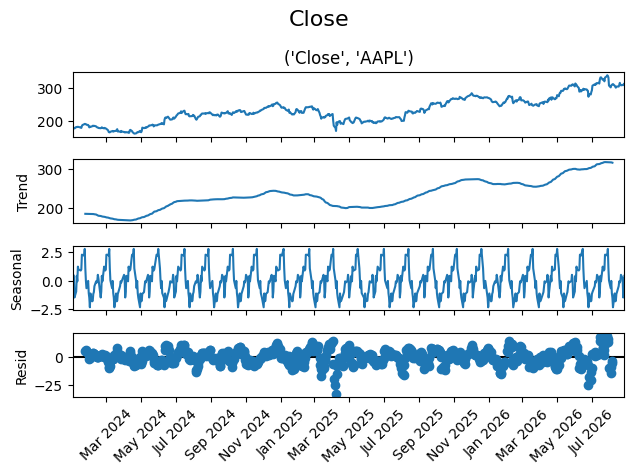

In [16]:
result=seasonal_decompose(
        df,model='additive',period=30)
fig=plt.figure(figsize=(14,5))
result.plot()
for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x',labelrotation=45)
plt.suptitle(col,fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
train_size = int(len(df) * 0.80)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

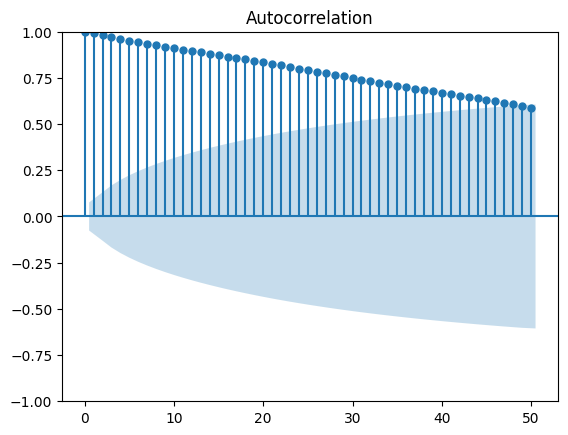

In [19]:
# for seasonality observation
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df, lags=50)
plt.show()

In [22]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=30
)
fit = model.fit(optimized=True)

forecast = fit.forecast(len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [23]:
from sklearn.metrics import *
mae = mean_absolute_error(
    test,
    forecast
)
rmse = np.sqrt(
    mean_squared_error(test, forecast)
)
mape = np.mean(
    np.abs(
        (test.values - forecast.values)
        / test.values
    )
) * 100


In [24]:
print("HOLT-WINTERS RESULTS")
print("--------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

HOLT-WINTERS RESULTS
--------------------
MAE : 26.110399383520907
RMSE: 31.94394862864495
MAPE: 8.580260387857491 %


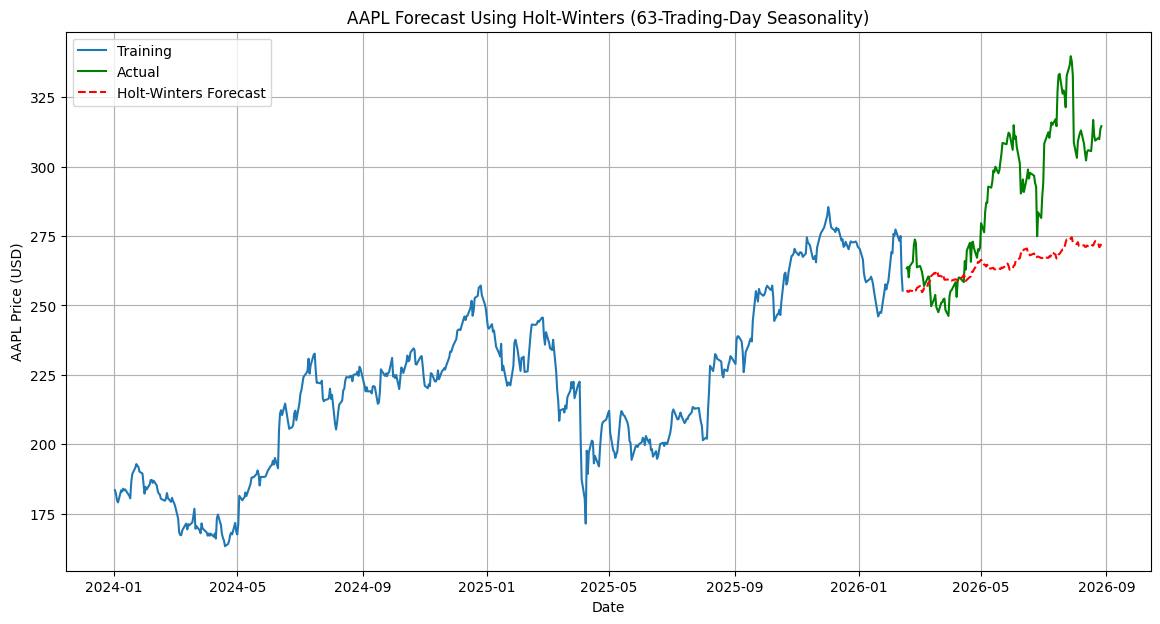

In [25]:
plt.figure(figsize=(14, 7))

plt.plot(train.index,train,label="Training")
plt.plot(test.index,test,label="Actual",color="green")
plt.plot(test.index,forecast,label="Holt-Winters Forecast", color="red",linestyle="--")
plt.title(
    "AAPL Forecast Using Holt-Winters "
    "(63-Trading-Day Seasonality)"
)

plt.xlabel("Date")
plt.ylabel("AAPL Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
periods = [5,7,14, 21, 63, 126, 252]
results = []

for period in periods:

    try:

        model = ExponentialSmoothing(
            train,
            trend="add",
            seasonal="add",
            seasonal_periods=period
        )

        fit = model.fit(
            optimized=True
        )

        forecast = fit.forecast(
            len(test)
        )

        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        mape = np.mean(
            np.abs(
                (test.values - forecast.values)
                / test.values
            )
        ) * 100

        results.append({
            "Seasonal Period": period,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    except Exception as e:
        print(
            f"Period {period} failed: {e}"
        )

results_df = pd.DataFrame(results)

print(results_df)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information

   Seasonal Period        MAE       RMSE      MAPE
0                5  16.921776  19.970695  5.993211
1                7  16.931698  19.928151  5.981326
2               14  16.910671  19.927208  5.988820
3               21  17.095696  20.013533  6.038337
4               63  17.681368  21.531607  6.376601
5              126  16.786909  19.757506  5.971480
6              252  18.622342  21.766161  6.597502


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [21]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=126
)
fit = model.fit(optimized=True)

forecast = fit.forecast(len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [22]:
from sklearn.metrics import *
mae = mean_absolute_error(
    test,
    forecast
)
rmse = np.sqrt(
    mean_squared_error(test, forecast)
)
mape = np.mean(
    np.abs(
        (test.values - forecast.values)
        / test.values
    )
) * 100


In [23]:
print("HOLT-WINTERS RESULTS")
print("--------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

HOLT-WINTERS RESULTS
--------------------
MAE : 16.78690913120857
RMSE: 19.757506023440293
MAPE: 5.971479695424814 %


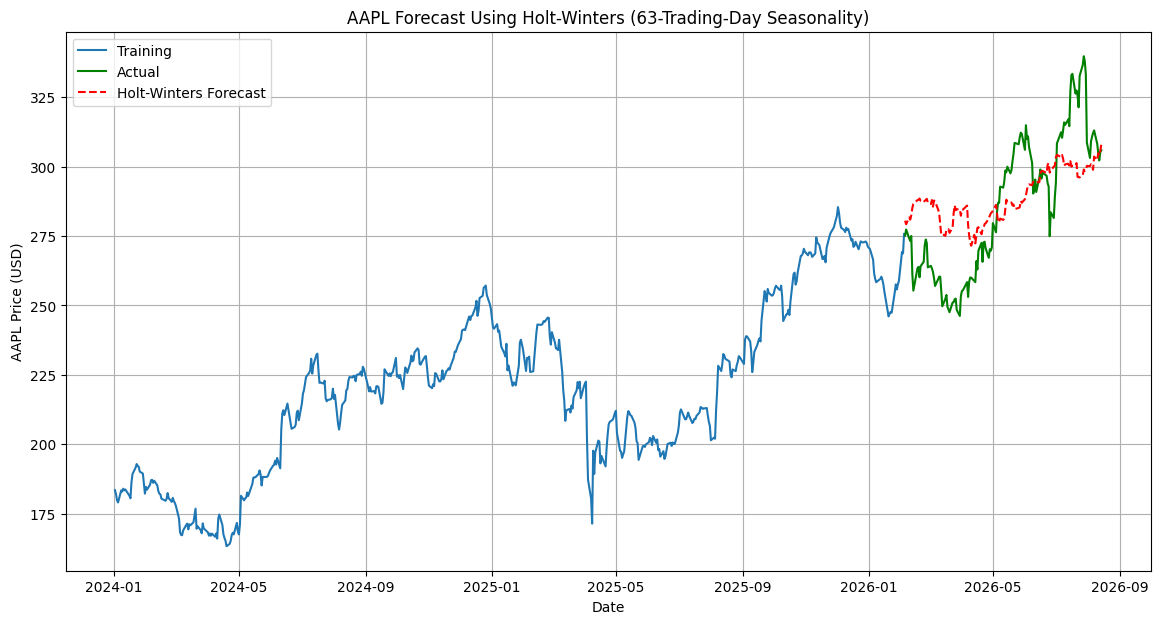

In [24]:
plt.figure(figsize=(14, 7))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual",
    color="green"
)

plt.plot(
    test.index,
    forecast,
    label="Holt-Winters Forecast",
    color="red",
    linestyle="--"
)

plt.title(
    "AAPL Forecast Using Holt-Winters "
    "(63-Trading-Day Seasonality)"
)

plt.xlabel("Date")
plt.ylabel("AAPL Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
print(fit.params)

{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(179.07156937056894), 'initial_trend': np.float64(0.18346847863505808), 'initial_seasons': array([  4.19029512,   4.46162082,   4.50844895,   3.68988477,
         5.06501443,   2.89697581,   3.06484439,   3.00666755,
         3.64237808,  -1.51026822,  -1.82531903,  -2.08333624,
        -1.58046752,   0.41706221,  -0.3173154 ,  -0.33346681,
         1.16205317,   0.86118169,   1.38643937,   0.91498519,
        -0.98790793,   3.59578268,   2.15144876,   4.43474524,
         3.43543773,   4.83874829,   7.26443255,   8.5674374 ,
         9.74123654,   9.72529828,   9.93203784,   8.93785431,
         8.25212887,   8.58971493,   8.67031216,   8.92437289,
         7.40796076,   6.64417693,   7.93549823,   5.38078324,
         7.38629104,   6.894043  ,   3.77365602,   2.21817138,
        -1.69164295,  -5.87732331,  -5.8